# Avance 3 - Baseline de detección de anomalías en vibración

El objetivo de esta libreta es construir un baseline reproducible para detectar comportamientos anómalos en mediciones de vibración de tres bombas. El conjunto de datos no incluye etiquetas reales de falla, por lo que la evaluación usa una etiqueta proxy de eventos extremos; esta etiqueta sirve como referencia inicial, no como sustituto de validación con fallas reales.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler

# Configuracion general
RANDOM_STATE = 42
ROLLING_WINDOW = 5
CONTAMINATION = 0.01
TRAIN_FRACTION = 0.70
PROXY_QUANTILE = 0.99
STATISTICAL_QUANTILE = 0.99

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "vibracion.csv"
OUTPUT_PATH = PROJECT_DIR / "baseline_anomalias.csv"

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Ambiente listo")
print(f"Directorio de trabajo: {PROJECT_DIR}")
print(f"Archivo de datos: {DATA_PATH.name} | existe: {DATA_PATH.exists()}")

Ambiente listo
Directorio de trabajo: /Users/leonardo/Documents/ProyectoIntegrador/ProyectoIntegradorMNA/Avance3.58/Baseline
Archivo de datos: vibracion.csv | existe: True


## 1. Carga y validación de datos

Se utiliza una ruta relativa porque `vibracion.csv` se entrega en la misma carpeta que la libreta. Esto permite que el notebook se ejecute en otra computadora sin depender de rutas locales de un integrante del equipo.

In [2]:
required_columns = [
    "timesTamp",
    "parameterName",
    "sensorId",
    "RMSVelocityH",
    "RMSVelocityV",
    "RMSVelocityA",
]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontro el archivo: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("Valores nulos por columna:")
print(df[required_columns].isna().sum())

df.head()

Filas: 52,560
Columnas: 6
Valores nulos por columna:
timesTamp        0
parameterName    0
sensorId         0
RMSVelocityH     0
RMSVelocityV     0
RMSVelocityA     0
dtype: int64


,timesTamp,parameterName,sensorId,RMSVelocityH,RMSVelocityV,RMSVelocityA
0,2025-01-01 00:00:00,Pump_1,189310001,0.2970,0.2550,0.3530
1,2025-01-01 00:30:00,Pump_1,189310001,0.2990,0.2430,0.3590
2,2025-01-01 01:00:00,Pump_1,189310001,0.2970,0.2480,0.3500
3,2025-01-01 01:30:00,Pump_1,189310001,0.3070,0.2470,0.3440
4,2025-01-01 02:00:00,Pump_1,189310001,0.3020,0.2560,0.3570


In [3]:
df["timesTamp"] = pd.to_datetime(df["timesTamp"])
df = df.sort_values(["parameterName", "sensorId", "timesTamp"]).reset_index(drop=True)

print("Rango temporal:")
print(df["timesTamp"].min(), "->", df["timesTamp"].max())

print("\nRegistros por bomba/sensor:")
print(df.groupby(["parameterName", "sensorId"]).size())

df.groupby("parameterName")[["RMSVelocityH", "RMSVelocityV", "RMSVelocityA"]].describe().round(4)

Rango temporal:
2025-01-01 00:00:00 -> 2025-12-31 23:30:00

Registros por bomba/sensor:
parameterName  sensorId 
Pump_1         189310001    17520
Pump_2         189310002    17520
Pump_3         189310003    17520
dtype: int64


RMSVelocityH                                                   \
                     count   mean    std    min    25%    50%    75%    max   
parameterName                                                                 
Pump_1          17520.0000 1.4589 0.4887 0.2970 0.9720 1.6070 1.8790 2.6670   
Pump_2          17520.0000 1.3134 0.3416 0.2930 1.0860 1.3275 1.5790 2.3860   
Pump_3          17520.0000 0.8332 0.3855 0.1370 0.4910 0.7820 1.1320 2.0220   

              RMSVelocityV                                                   \
                     count   mean    std    min    25%    50%    75%    max   
parameterName                                                                 
Pump_1          17520.0000 1.7168 0.8055 0.2430 0.8250 1.9205 2.4410 3.3470   
Pump_2          17520.0000 1.1512 0.4277 0.2430 0.8020 1.2350 1.4420 2.4900   
Pump_3          17520.0000 1.4456 0.8831 0.0570 0.4990 1.3970 2.2510 3.6440   

              RMSVelocityA                                                   
                     count   mean    std    min    25%    50%    75%    max  
parameterName                                                                
Pump_1          17520.0000 1.7639 0.7231 0.3440 0.9440 2.1870 2.3520 3.0180  
Pump_2          17520.0000 0.9253 0.4279 0.1100 0.6130 0.9630 1.1610 2.1970  
Pump_3          17520.0000 1.4668 0.4017 0.3430 1.1610 1.5290 1.8240 2.5390

## 2. Algoritmo baseline

**Pregunta: ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo?**

El problema se aborda como detección de anomalías sobre datos estructurados de sensores. Como no hay etiquetas reales de falla, se proponen dos referencias:

- **Regla estadística por sensor:** baseline mínimo e interpretable. Marca anomalías cuando la energía o el máximo RMS superan percentiles altos aprendidos en entrenamiento.
- **Isolation Forest:** baseline de aprendizaje automático no supervisado, adecuado para detectar observaciones raras en variables numéricas sin necesitar etiquetas. Es razonable para este caso porque los datos son tabulares, hay suficientes registros y se requiere una solución simple antes de modelos más complejos.

Isolation Forest se entrena solo con el tramo inicial de la serie temporal para simular un escenario realista: aprender el comportamiento base y evaluar datos posteriores.

In [4]:
# =====================================================
# 2. FEATURE ENGINEERING
# =====================================================

group_cols = ["parameterName", "sensorId"]
rms_cols = ["RMSVelocityH", "RMSVelocityV", "RMSVelocityA"]

df["energy"] = (df["RMSVelocityH"] ** 2) + (df["RMSVelocityV"] ** 2) + (df["RMSVelocityA"] ** 2)
df["rms_magnitude"] = np.sqrt(df["energy"])
df["max_rms"] = df[rms_cols].max(axis=1)

grouped = df.groupby(group_cols, group_keys=False)
for col in rms_cols + ["energy"]:
    df[f"{col}_rolling_mean_{ROLLING_WINDOW}"] = grouped[col].transform(
        lambda s: s.rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean()
    )
    df[f"{col}_rolling_std_{ROLLING_WINDOW}"] = grouped[col].transform(
        lambda s: s.rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).std()
    )
    df[f"{col}_diff_abs"] = grouped[col].transform(lambda s: s.diff().abs())

df["hour"] = df["timesTamp"].dt.hour
df["day_of_week"] = df["timesTamp"].dt.dayofweek

df = df.dropna().reset_index(drop=True)

print(f"Filas despues de feature engineering: {df.shape[0]:,}")
print(f"Columnas disponibles: {df.shape[1]}")
df.head()

Filas despues de feature engineering: 52,548
Columnas disponibles: 23


,timesTamp,parameterName,sensorId,RMSVelocityH,RMSVelocityV,RMSVelocityA,energy,rms_magnitude,max_rms,RMSVelocityH_rolling_mean_5,RMSVelocityH_rolling_std_5,RMSVelocityH_diff_abs,RMSVelocityV_rolling_mean_5,RMSVelocityV_rolling_std_5,RMSVelocityV_diff_abs,RMSVelocityA_rolling_mean_5,RMSVelocityA_rolling_std_5,RMSVelocityA_diff_abs,energy_rolling_mean_5,energy_rolling_std_5,energy_diff_abs,hour,day_of_week
0,2025-01-01 02:00:00,Pump_1,189310001,0.3020,0.2560,0.3570,0.2842,0.5331,0.3570,0.3004,0.0042,0.0050,0.2498,0.0055,0.0090,0.3526,0.0059,0.0130,0.2770,0.0047,0.0106,2,2
1,2025-01-01 02:30:00,Pump_1,189310001,0.3120,0.2500,0.3490,0.2816,0.5307,0.3490,0.3034,0.0061,0.0100,0.2488,0.0048,0.0060,0.3518,0.0061,0.0080,0.2778,0.0051,0.0025,2,2
2,2025-01-01 03:00:00,Pump_1,189310001,0.2990,0.2600,0.3530,0.2816,0.5307,0.3530,0.3034,0.0061,0.0130,0.2522,0.0056,0.0100,0.3506,0.0048,0.0040,0.2787,0.0054,0.0000,3,2
3,2025-01-01 03:30:00,Pump_1,189310001,0.3030,0.2440,0.3590,0.2802,0.5294,0.3590,0.3046,0.0050,0.0040,0.2514,0.0065,0.0160,0.3524,0.0061,0.0060,0.2803,0.0040,0.0014,3,2
4,2025-01-01 04:00:00,Pump_1,189310001,0.3080,0.2430,0.3570,0.2814,0.5304,0.3570,0.3048,0.0052,0.0050,0.2506,0.0074,0.0010,0.3550,0.0040,0.0020,0.2818,0.0015,0.0011,4,2


In [5]:
FEATURE_COLUMNS = [
    "RMSVelocityH",
    "RMSVelocityV",
    "RMSVelocityA",
    "energy",
    "rms_magnitude",
    "max_rms",
    f"RMSVelocityH_rolling_mean_{ROLLING_WINDOW}",
    f"RMSVelocityV_rolling_mean_{ROLLING_WINDOW}",
    f"RMSVelocityA_rolling_mean_{ROLLING_WINDOW}",
    f"energy_rolling_mean_{ROLLING_WINDOW}",
    f"RMSVelocityH_rolling_std_{ROLLING_WINDOW}",
    f"RMSVelocityV_rolling_std_{ROLLING_WINDOW}",
    f"RMSVelocityA_rolling_std_{ROLLING_WINDOW}",
    f"energy_rolling_std_{ROLLING_WINDOW}",
    "RMSVelocityH_diff_abs",
    "RMSVelocityV_diff_abs",
    "RMSVelocityA_diff_abs",
    "energy_diff_abs",
    "hour",
    "day_of_week",
]

print(f"Numero de caracteristicas usadas: {len(FEATURE_COLUMNS)}")
FEATURE_COLUMNS

Numero de caracteristicas usadas: 20


['RMSVelocityH',
 'RMSVelocityV',
 'RMSVelocityA',
 'energy',
 'rms_magnitude',
 'max_rms',
 'RMSVelocityH_rolling_mean_5',
 'RMSVelocityV_rolling_mean_5',
 'RMSVelocityA_rolling_mean_5',
 'energy_rolling_mean_5',
 'RMSVelocityH_rolling_std_5',
 'RMSVelocityV_rolling_std_5',
 'RMSVelocityA_rolling_std_5',
 'energy_rolling_std_5',
 'RMSVelocityH_diff_abs',
 'RMSVelocityV_diff_abs',
 'RMSVelocityA_diff_abs',
 'energy_diff_abs',
 'hour',
 'day_of_week']

## 3. Etiqueta proxy para evaluación

El archivo no contiene una variable objetivo real de falla. Para poder calcular métricas como precision, recall y F1, se crea una **etiqueta proxy**: se considera evento extremo cuando `energy` o `max_rms` están por encima del percentil 99 por bomba/sensor.

Esta etiqueta no debe interpretarse como verdad operacional. Su función es dar un marco inicial de comparación; si en el futuro se agregan bitácoras de mantenimiento o fallas reales, esta sección debe reemplazarse por esas etiquetas.

In [6]:
proxy_thresholds = (
    df.groupby(group_cols)[["energy", "max_rms"]]
    .quantile(PROXY_QUANTILE)
    .rename(columns={"energy": "energy_proxy_threshold", "max_rms": "max_rms_proxy_threshold"})
    .reset_index()
)

df = df.merge(proxy_thresholds, on=group_cols, how="left")
df["proxy_anomaly"] = (
    (df["energy"] >= df["energy_proxy_threshold"])
    | (df["max_rms"] >= df["max_rms_proxy_threshold"])
)

proxy_summary = (
    df.groupby("parameterName")["proxy_anomaly"]
    .agg(eventos="sum", registros="count", tasa="mean")
    .reset_index()
)

print("Eventos extremos proxy por bomba:")
print(proxy_summary)

Eventos extremos proxy por bomba:
  parameterName  eventos  registros   tasa
0        Pump_1      216      17516 0.0123
1        Pump_2      291      17516 0.0166
2        Pump_3      231      17516 0.0132


## 4. Características importantes

**Pregunta: ¿Se puede determinar la importancia de las características para el modelo generado?**

Sí. En este baseline se usa un método **filter**: la correlación absoluta entre cada característica numérica y la etiqueta proxy. No implica causalidad, pero ayuda a identificar qué variables se asocian más con eventos extremos y cuáles podrían ser ruido.

Para modelos posteriores conviene priorizar las variables con mayor relación con vibración/energía y revisar las variables de baja relevancia antes de aumentar la complejidad.

Top 10 caracteristicas por correlacion absoluta con la etiqueta proxy:
                       feature  abs_correlation  correlation
0                      max_rms           0.1834       0.1834
1                 RMSVelocityV           0.1793       0.1793
2              energy_diff_abs           0.1775       0.1775
3  RMSVelocityV_rolling_mean_5           0.1747       0.1747
4                       energy           0.1742       0.1742
5        energy_rolling_mean_5           0.1668       0.1668
6                rms_magnitude           0.1567       0.1567
7         energy_rolling_std_5           0.1273       0.1273
8                 RMSVelocityA           0.1106       0.1106
9  RMSVelocityA_rolling_mean_5           0.1081       0.1081


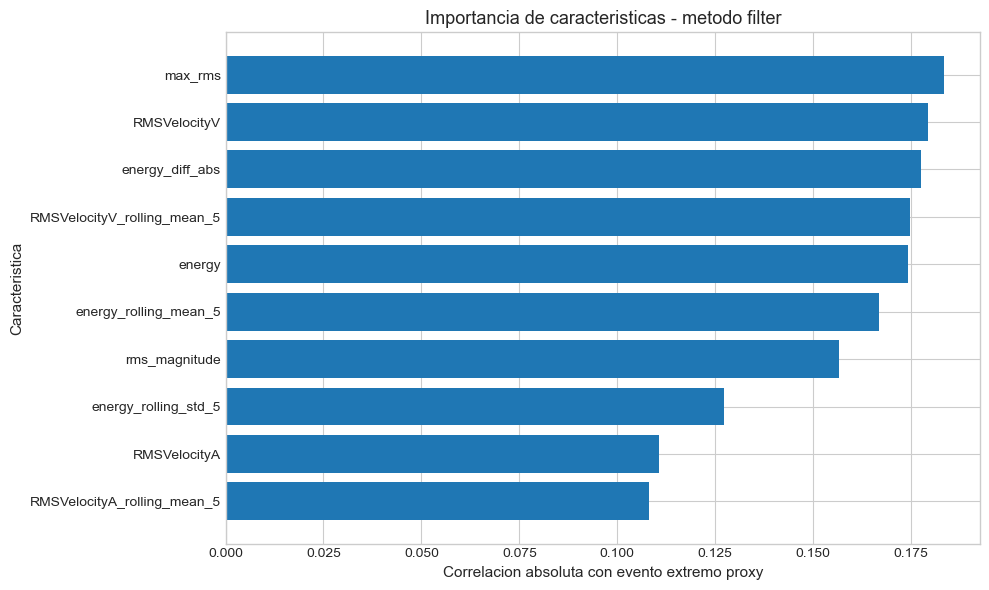

In [7]:
importance_rows = []
for feature in FEATURE_COLUMNS:
    corr_value = df[[feature, "proxy_anomaly"]].corr(numeric_only=True).iloc[0, 1]
    importance_rows.append({"feature": feature, "abs_correlation": abs(corr_value), "correlation": corr_value})

feature_importance = (
    pd.DataFrame(importance_rows)
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 caracteristicas por correlacion absoluta con la etiqueta proxy:")
print(feature_importance.head(10))

top_features = feature_importance.head(10).sort_values("abs_correlation")
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["abs_correlation"])
plt.title("Importancia de caracteristicas - metodo filter")
plt.xlabel("Correlacion absoluta con evento extremo proxy")
plt.ylabel("Caracteristica")
plt.tight_layout()
plt.show()

## 5. División temporal entrenamiento/prueba

Para evitar fuga de información temporal, el baseline se entrena con el primer 70% de los registros y se evalúa con el 30% posterior. Este criterio es más realista que una partición aleatoria porque en producción se entrenaría con datos históricos y se usaría el modelo sobre mediciones futuras.

In [8]:
split_time = df["timesTamp"].quantile(TRAIN_FRACTION)
train_mask = df["timesTamp"] <= split_time
test_mask = ~train_mask
df["split"] = np.where(train_mask, "train", "test")

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

print(f"Fecha de corte: {split_time}")
print(f"Entrenamiento: {train_df.shape[0]:,} filas ({train_df['timesTamp'].min()} -> {train_df['timesTamp'].max()})")
print(f"Prueba: {test_df.shape[0]:,} filas ({test_df['timesTamp'].min()} -> {test_df['timesTamp'].max()})")
print("\nTasa proxy train/test:")
print(pd.Series({"train": train_df["proxy_anomaly"].mean(), "test": test_df["proxy_anomaly"].mean()}))

Fecha de corte: 2025-09-13 12:27:00
Entrenamiento: 36,783 filas (2025-01-01 02:00:00 -> 2025-09-13 12:00:00)
Prueba: 15,765 filas (2025-09-13 12:30:00 -> 2025-12-31 23:30:00)

Tasa proxy train/test:
train   0.0010
test    0.0446
dtype: float64


In [9]:
# =====================================================
# 5. BASELINE ESTADISTICO
# =====================================================

stat_thresholds = (
    train_df.groupby(group_cols)[["energy", "max_rms"]]
    .quantile(STATISTICAL_QUANTILE)
    .rename(columns={"energy": "energy_stat_threshold", "max_rms": "max_rms_stat_threshold"})
    .reset_index()
)

df = df.drop(columns=["energy_stat_threshold", "max_rms_stat_threshold"], errors="ignore")
df = df.merge(stat_thresholds, on=group_cols, how="left")
df["statistical_anomaly"] = (
    (df["energy"] >= df["energy_stat_threshold"])
    | (df["max_rms"] >= df["max_rms_stat_threshold"])
)

print("Cantidad de anomalías por regla estadística:")
print(df.groupby("parameterName")["statistical_anomaly"].agg(anomalias="sum", registros="count", tasa="mean"))

Cantidad de anomalías por regla estadística:
               anomalias  registros   tasa
parameterName                             
Pump_1              1133      17516 0.0647
Pump_2              4215      17516 0.2406
Pump_3              5440      17516 0.3106


In [10]:
# =====================================================
# 6. BASELINE ISOLATION FOREST
# =====================================================

scaler = MinMaxScaler()
X_train = scaler.fit_transform(df.loc[train_mask, FEATURE_COLUMNS])
X_test = scaler.transform(df.loc[test_mask, FEATURE_COLUMNS])

iso_model = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
)
iso_model.fit(X_train)

train_predictions = iso_model.predict(X_train)
test_predictions = iso_model.predict(X_test)

df["if_anomaly"] = 1
df.loc[train_mask, "if_anomaly"] = train_predictions
df.loc[test_mask, "if_anomaly"] = test_predictions

df["if_anomaly_bool"] = df["if_anomaly"].eq(-1)
df["if_anomaly_score"] = np.nan
df.loc[train_mask, "if_anomaly_score"] = -iso_model.score_samples(X_train)
df.loc[test_mask, "if_anomaly_score"] = -iso_model.score_samples(X_test)

print("Cantidad de anomalías por Isolation Forest:")
print(df.groupby("parameterName")["if_anomaly_bool"].agg(anomalias="sum", registros="count", tasa="mean"))

Cantidad de anomalías por Isolation Forest:
               anomalias  registros   tasa
parameterName                             
Pump_1               440      17516 0.0251
Pump_2               187      17516 0.0107
Pump_3               256      17516 0.0146


## 6. Métrica y desempeño mínimo

**Pregunta: ¿Cuál es la métrica adecuada para este problema de negocio?**

La métrica principal debe ser **recall**, porque no detectar una falla potencial puede implicar paro de equipo, daño mecánico o costos de mantenimiento mayores. También se reportan **precision** y **F1-score** para controlar falsos positivos, ya que demasiadas alarmas pueden desgastar la operación.

**Pregunta: ¿Cuál debería ser el desempeño mínimo a obtener?**

Como no existe un histórico etiquetado de fallas, el desempeño mínimo se define contra la etiqueta proxy: en prueba, el baseline debe alcanzar `recall >= 0.70` y una `precision` superior a la tasa base de eventos extremos en el conjunto de prueba. Este umbral es inicial y debe ajustarse cuando existan etiquetas reales del negocio.

In [11]:
def evaluate_predictions(model_name, split_name, mask, prediction_col):
    y_true = df.loc[mask, "proxy_anomaly"].astype(int)
    y_pred = df.loc[mask, prediction_col].astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "modelo": model_name,
        "split": split_name,
        "registros": int(mask.sum()),
        "tasa_proxy": y_true.mean(),
        "tasa_alerta": y_pred.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

metrics = pd.DataFrame([
    evaluate_predictions("Regla estadistica", "train", train_mask, "statistical_anomaly"),
    evaluate_predictions("Regla estadistica", "test", test_mask, "statistical_anomaly"),
    evaluate_predictions("Isolation Forest", "train", train_mask, "if_anomaly_bool"),
    evaluate_predictions("Isolation Forest", "test", test_mask, "if_anomaly_bool"),
])

base_rate_test = df.loc[test_mask, "proxy_anomaly"].mean()
metrics["cumple_minimo"] = (metrics["split"].eq("test")) & (metrics["recall"] >= 0.70) & (metrics["precision"] > base_rate_test)

metrics.round(4)

,modelo,split,registros,tasa_proxy,tasa_alerta,accuracy,precision,recall,f1,tp,fp,tn,fn,cumple_minimo
0,Regla estadistica,train,36783,0.0010,0.0150,0.9859,0.0634,1.0000,0.1193,35,517,36231,0,False
1,Regla estadistica,test,15765,0.0446,0.6493,0.3953,0.0687,1.0000,0.1285,703,9533,5529,0,True
2,Isolation Forest,train,36783,0.0010,0.0100,0.9909,0.0951,1.0000,0.1737,35,333,36415,0,False
3,Isolation Forest,test,15765,0.0446,0.0327,0.9386,0.2427,0.1778,0.2053,125,390,14672,578,False


## 7. Subajuste / sobreajuste

**Pregunta: ¿El modelo está sub/sobreajustando los datos de entrenamiento?**

Se compara el desempeño en entrenamiento y prueba usando la misma etiqueta proxy. Una señal de sobreajuste sería buen desempeño en entrenamiento y caída fuerte en prueba. Una señal de subajuste sería bajo recall/F1 en ambos conjuntos o una tasa de alerta demasiado baja para detectar eventos extremos.

En este baseline, la interpretación debe centrarse en estabilidad y utilidad operativa: la regla estadística es simple e interpretable, pero puede generar muchas alertas si la distribución futura cambia; Isolation Forest es más conservador, pero con `contamination=0.01` puede quedarse corto en recall si el objetivo de negocio es detectar la mayoría de eventos extremos.

Resumen de score de anomalía Isolation Forest:
           count   mean    std    min    25%    50%    75%    max
split                                                            
test  15765.0000 0.5041 0.0576 0.3824 0.4664 0.5044 0.5356 0.7364
train 36783.0000 0.4399 0.0557 0.3705 0.4019 0.4169 0.4647 0.7243


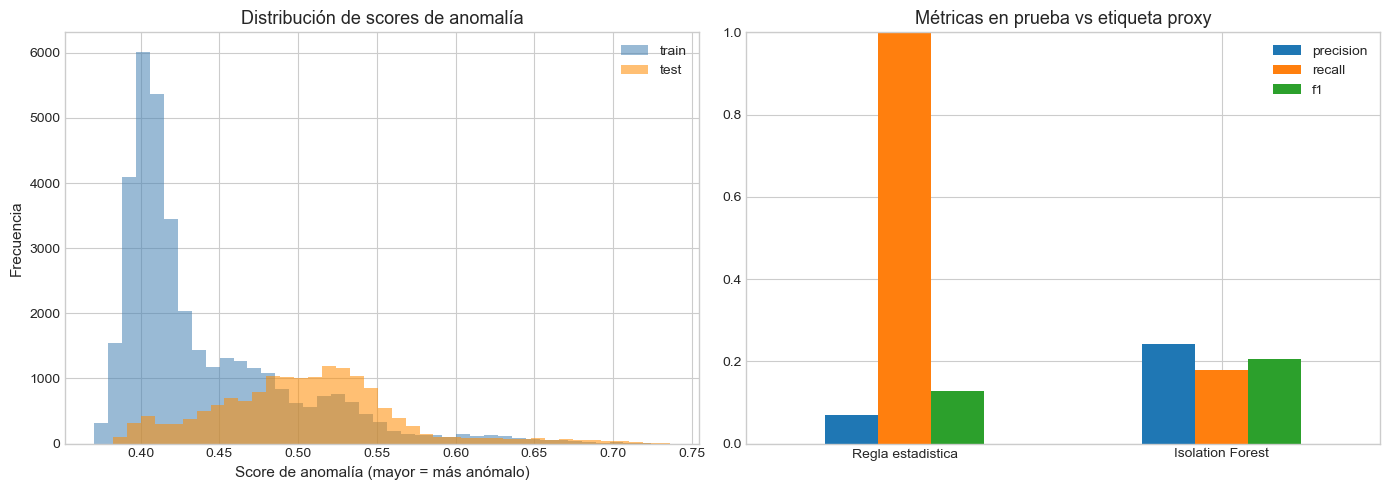

In [12]:
score_summary = df.groupby("split")["if_anomaly_score"].describe().round(4)
print("Resumen de score de anomalía Isolation Forest:")
print(score_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split_name, mask, color in [("train", train_mask, "steelblue"), ("test", test_mask, "darkorange")]:
    axes[0].hist(df.loc[mask, "if_anomaly_score"], bins=40, alpha=0.55, label=split_name, color=color)
axes[0].set_title("Distribución de scores de anomalía")
axes[0].set_xlabel("Score de anomalía (mayor = más anómalo)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

plot_metrics = metrics[metrics["split"].eq("test")].set_index("modelo")[["precision", "recall", "f1"]]
plot_metrics.plot(kind="bar", ax=axes[1])
axes[1].set_title("Métricas en prueba vs etiqueta proxy")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

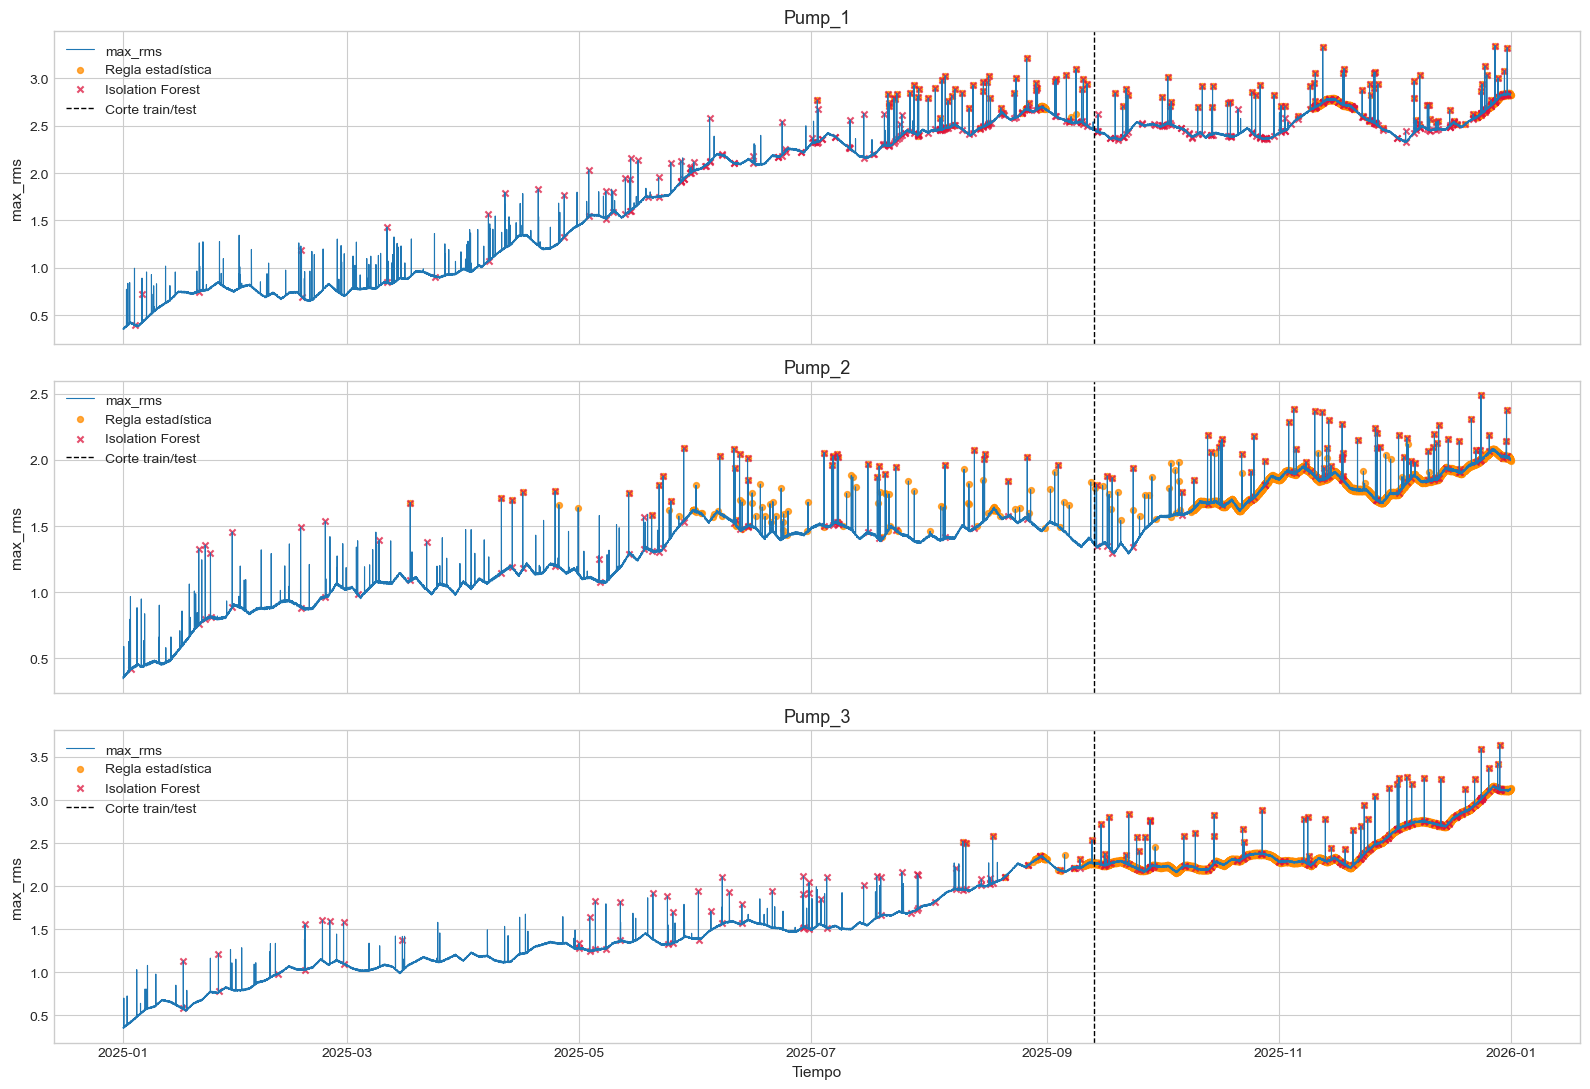

In [13]:
# =====================================================
# 8. VISUALIZACION TEMPORAL DE ALERTAS
# =====================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

for ax, (pump_name, pump_df) in zip(axes, df.groupby("parameterName")):
    ax.plot(pump_df["timesTamp"], pump_df["max_rms"], linewidth=0.8, label="max_rms")

    stat_alerts = pump_df[pump_df["statistical_anomaly"]]
    if_alerts = pump_df[pump_df["if_anomaly_bool"]]

    ax.scatter(stat_alerts["timesTamp"], stat_alerts["max_rms"], s=18, color="darkorange", label="Regla estadística", alpha=0.75)
    ax.scatter(if_alerts["timesTamp"], if_alerts["max_rms"], s=20, color="crimson", marker="x", label="Isolation Forest", alpha=0.75)
    ax.axvline(split_time, color="black", linestyle="--", linewidth=1, label="Corte train/test")
    ax.set_title(pump_name)
    ax.set_ylabel("max_rms")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Tiempo")
plt.tight_layout()
plt.show()

## 8. Conclusiones del baseline

El baseline estadístico funciona como referencia mínima por su interpretabilidad y porque permite explicar claramente cuándo se genera una alerta. Isolation Forest agrega una comparación no supervisada más flexible, pero su desempeño depende del parámetro `contamination` y de la estabilidad de la distribución temporal.

Para una siguiente iteración, el avance más importante sería incorporar etiquetas reales de mantenimiento/falla. Con esas etiquetas se podrían recalibrar umbrales, optimizar `contamination`, usar validación temporal más formal y comparar modelos más avanzados con una métrica de negocio real.

In [14]:
# =====================================================
# 9. EXPORTAR RESULTADOS
# =====================================================

export_columns = [
    "timesTamp",
    "parameterName",
    "sensorId",
    "RMSVelocityH",
    "RMSVelocityV",
    "RMSVelocityA",
    "energy",
    "rms_magnitude",
    "max_rms",
    "proxy_anomaly",
    "split",
    "statistical_anomaly",
    "if_anomaly",
    "if_anomaly_bool",
    "if_anomaly_score",
]

for col in FEATURE_COLUMNS:
    if col not in export_columns:
        export_columns.append(col)

df[export_columns].to_csv(OUTPUT_PATH, index=False)

print(f"Archivo generado: {OUTPUT_PATH.name}")
print(f"Filas exportadas: {df.shape[0]:,}")

Archivo generado: baseline_anomalias.csv
Filas exportadas: 52,548
